In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/monthly_gdp_indicators.csv')
print(df.shape)
df.head(10)

(9477, 7)


,v4_0,mmm-yy,Time,uk-only,Geography,sic-unofficial,UnofficialStandardIndustrialClassification
0,99.3484,Mar-26,Mar-26,K02000001,United Kingdom,P,P : Education
1,102.4678,Mar-26,Mar-26,K02000001,United Kingdom,R,"R : Arts, Entertainment and Recreation"
2,109.2320,Mar-26,Mar-26,K02000001,United Kingdom,Q,Q : Human health and social work activities
3,102.1860,Mar-26,Mar-26,K02000001,United Kingdom,K--N,K-N : Business Services and Finance
4,94.8418,Mar-26,Mar-26,K02000001,United Kingdom,D,"D : Electricity, gas steam and air conditioning"
5,110.9317,Mar-26,Mar-26,K02000001,United Kingdom,H,H : Transportation and storage
6,98.3408,Mar-26,Mar-26,K02000001,United Kingdom,T,T : Activities of Households as employers
7,104.4547,Mar-26,Mar-26,K02000001,United Kingdom,G--T,G-T : Index of Services
8,115.0275,Mar-26,Mar-26,K02000001,United Kingdom,J,J : Information and communication
9,103.5551,Mar-26,Mar-26,K02000001,United Kingdom,M,"M : Professional, scientific and technical act..."


In [2]:
df[['sic-unofficial', 'UnofficialStandardIndustrialClassification']].drop_duplicates()

,sic-unofficial,UnofficialStandardIndustrialClassification
0,P,P : Education
1,R,"R : Arts, Entertainment and Recreation"
2,Q,Q : Human health and social work activities
3,K--N,K-N : Business Services and Finance
4,D,"D : Electricity, gas steam and air conditioning"
5,H,H : Transportation and storage
6,T,T : Activities of Households as employers
7,G--T,G-T : Index of Services
8,J,J : Information and communication
9,M,"M : Professional, scientific and technical act..."


In [3]:
codes = ['A--T', 'G--T', 'B--E']
df_filtered = df[df['sic-unofficial'].isin(codes)].copy()
print(df_filtered.shape)
df_filtered.head(10)

(1053, 7)


,v4_0,mmm-yy,Time,uk-only,Geography,sic-unofficial,UnofficialStandardIndustrialClassification
7,104.4547,Mar-26,Mar-26,K02000001,United Kingdom,G--T,G-T : Index of Services
11,98.7305,Mar-26,Mar-26,K02000001,United Kingdom,B--E,B-E : Production Industries
12,103.3960,Mar-26,Mar-26,K02000001,United Kingdom,A--T,A-T : Monthly GDP
39,103.0882,Feb-26,Feb-26,K02000001,United Kingdom,A--T,A-T : Monthly GDP
52,104.1359,Feb-26,Feb-26,K02000001,United Kingdom,G--T,G-T : Index of Services
53,98.9293,Feb-26,Feb-26,K02000001,United Kingdom,B--E,B-E : Production Industries
54,103.6687,Jan-26,Jan-26,K02000001,United Kingdom,G--T,G-T : Index of Services
60,98.6337,Jan-26,Jan-26,K02000001,United Kingdom,B--E,B-E : Production Industries
69,102.6536,Jan-26,Jan-26,K02000001,United Kingdom,A--T,A-T : Monthly GDP
97,98.7667,Dec-25,Dec-25,K02000001,United Kingdom,B--E,B-E : Production Industries


In [4]:
df_wide = df_filtered.pivot(index='mmm-yy', columns='sic-unofficial', values='v4_0')
df_wide = df_wide.rename(columns={'A--T': 'monthly_gdp', 'G--T': 'index_services', 'B--E': 'index_production'})
print(df_wide.shape)
df_wide.head(10)


(351, 3)


sic-unofficial,monthly_gdp,index_production,index_services
mmm-yy,,,
Apr-00,69.0325,96.3436,63.5032
Apr-01,71.1731,100.7018,65.4106
Apr-02,72.5641,99.9677,67.1494
Apr-03,74.4262,105.2415,68.7014
Apr-04,75.9848,107.3912,70.3772
Apr-05,78.4325,105.6813,73.5307
Apr-06,80.2487,109.2585,75.2684
Apr-07,82.3414,107.5203,78.1386
Apr-08,84.7375,109.7604,80.7909


In [5]:
df_wide = df_wide.reset_index()
df_wide['date'] = pd.to_datetime(df_wide['mmm-yy'], format='%b-%y')
df_wide = df_wide.sort_values('date').reset_index(drop=True)
df_wide.head(10)


sic-unofficial,mmm-yy,monthly_gdp,index_production,index_services,date
0,Jan-97,61.6483,85.6935,57.1761,1997-01-01
1,Feb-97,61.9102,85.8179,57.4444,1997-02-01
2,Mar-97,61.8159,84.5259,57.5270,1997-03-01
3,Apr-97,62.5811,86.4647,58.0228,1997-04-01
4,May-97,62.0561,85.7999,57.4543,1997-05-01
5,Jun-97,62.5359,86.1305,58.0092,1997-06-01
6,Jul-97,62.7982,87.6552,58.0546,1997-07-01
7,Aug-97,62.8146,86.5465,58.3044,1997-08-01
8,Sep-97,62.9932,87.1141,58.3929,1997-09-01
9,Oct-97,63.4074,88.3427,58.6052,1997-10-01


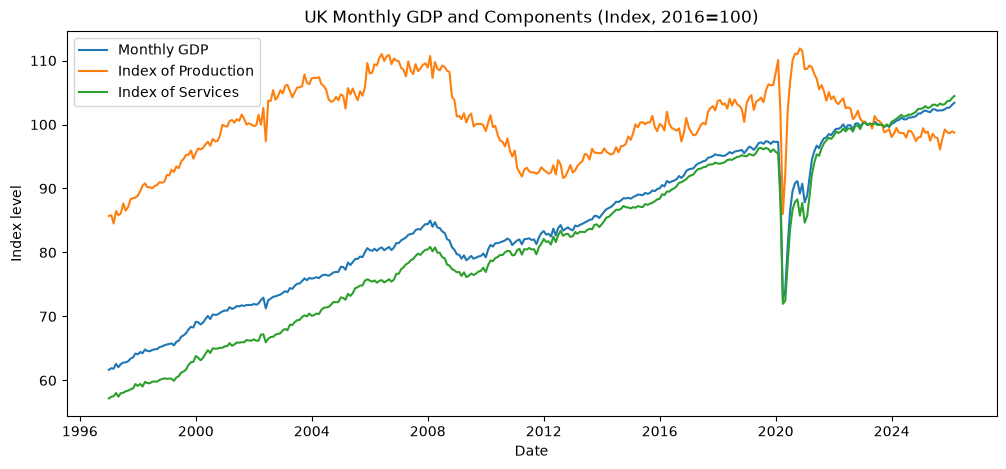

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df_wide['date'], df_wide['monthly_gdp'], label='Monthly GDP')
plt.plot(df_wide['date'], df_wide['index_production'], label='Index of Production')
plt.plot(df_wide['date'], df_wide['index_services'], label='Index of Services')
plt.title('UK Monthly GDP and Components (Index, 2016=100)')
plt.xlabel('Date')
plt.ylabel('Index level')
plt.legend()
plt.show()

In [7]:
from statsmodels.tsa.stattools import adfuller

for col in ['monthly_gdp', 'index_production', 'index_services']:
    result = adfuller(df_wide[col])
    print(f"{col}: ADF stat={result[0]:.3f}, p-value={result[1]:.4f}")

monthly_gdp: ADF stat=-1.101, p-value=0.7146
index_production: ADF stat=-2.757, p-value=0.0648
index_services: ADF stat=-0.906, p-value=0.7860


In [8]:
df_wide['gdp_growth'] = df_wide['monthly_gdp'].pct_change() * 100
df_wide['production_growth'] = df_wide['index_production'].pct_change() * 100
df_wide['services_growth'] = df_wide['index_services'].pct_change() * 100

df_wide = df_wide.dropna().reset_index(drop=True)

for col in ['gdp_growth', 'production_growth', 'services_growth']:
    result = adfuller(df_wide[col])
    print(f"{col}: ADF stat={result[0]:.3f}, p-value={result[1]:.4f}")

gdp_growth: ADF stat=-11.135, p-value=0.0000
production_growth: ADF stat=-13.644, p-value=0.0000
services_growth: ADF stat=-10.721, p-value=0.0000
